In [21]:
# INSTALAÇÃO DO OLLAMA
!apt-get update -qq
!apt-get install -y zstd

!curl -fsSL https://ollama.com/install.sh | sh

!pip install ollama -q

print("Instalação finalizada.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 27 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Instalação finalizada.


In [22]:
# INICIAR O SERVIDOR OLLAMA

import time
import requests

# Fecha instâncias antigas
!pkill ollama || true

# Inicia servidor
!nohup ollama serve > ollama.log 2>&1 &

# Espera iniciar
time.sleep(10)

# Verifica servidor
try:
    resposta = requests.get(
        "http://127.0.0.1:11434/api/tags",
        timeout=5
    )

    print("Servidor Ollama ativo.")

except Exception as erro:
    print("Erro ao iniciar Ollama.")
    print(erro)

# Baixar modelo
!ollama pull llama3.2:1b

print("Modelo carregado.")

Servidor Ollama ativo.

Modelo carregado.


In [23]:
# CENÁRIOS DA MISSÃO
cenarios_missao = [

    {
        "nome": "Cenário Normal",
        "temperatura": 24,
        "energia": 82,
        "comunicacao": "estável",
        "oxigenio": 96,
        "radiacao": 0.3,
        "status_modulo": "operacional"
    },

    {
        "nome": "Cenário de Atenção",
        "temperatura": 66,
        "energia": 42,
        "comunicacao": "estável",
        "oxigenio": 92,
        "radiacao": 0.8,
        "status_modulo": "atenção"
    },

    {
        "nome": "Cenário Crítico",
        "temperatura": 95,
        "energia": 18,
        "comunicacao": "instável",
        "oxigenio": 71,
        "radiacao": 2.8,
        "status_modulo": "crítico"
    }
]

print("Cenários simulados carregados.")

Cenários simulados carregados.


In [24]:
# IMPORTS E CONFIGURAÇÕES
import ollama
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

MODELO_IA = "llama3.2:1b"

SYSTEM_PROMPT = """
Você é uma inteligência artificial chamada Mission Control AI.

Sua função é monitorar uma missão espacial experimental.

Analise:
- temperatura
- energia
- comunicação
- oxigênio
- radiação
- status operacional

Responda sempre:
1. Nível de risco
2. Problemas encontrados
3. Consequências possíveis
4. Ações recomendadas

Responda de forma extremamente curta.
Máximo de 4 linhas.
Não invente riscos inexistentes.
Use linguagem técnica.
"""
print("Configurações carregadas.")

Configurações carregadas.


In [49]:
# FUNÇÕES PRINCIPAIS DO SISTEMA
from datetime import datetime
import requests
import subprocess
import time

# GERAR ALERTAS
def gerar_alertas(cenario):
    alertas = []
    acoes = []

    temperatura = cenario["temperatura"]
    energia = cenario["energia"]
    comunicacao = cenario["comunicacao"]
    oxigenio = cenario["oxigenio"]
    radiacao = cenario["radiacao"]

    # TEMPERATURA
    if temperatura >= 85:
        alertas.append("Temperatura crítica detectada")
        acoes.append("Ativar sistema de resfriamento")
    elif temperatura >= 65:
        alertas.append("Temperatura acima do ideal")
        acoes.append("Reduzir carga operacional")

    # ENERGIA
    if energia <= 20:
        alertas.append("Energia abaixo do nível seguro")
        acoes.append("Ativar economia de energia")
    elif energia <= 40:
        alertas.append("Energia em nível de atenção")
        acoes.append("Monitorar consumo energético")

    # COMUNICAÇÃO
    if comunicacao.lower() == "instável":
        alertas.append("Comunicação instável")
        acoes.append("Reiniciar canal de comunicação")
    elif comunicacao.lower() == "offline":
        alertas.append("Comunicação perdida")
        acoes.append("Ativar protocolo automático")

    # OXIGÊNIO
    if oxigenio <= 75:
        alertas.append("Oxigênio crítico")
        acoes.append("Liberar reserva de oxigênio")
    elif oxigenio <= 90:
        alertas.append("Oxigênio abaixo do ideal")
        acoes.append("Monitorar suporte de vida")

    # RADIAÇÃO
    if radiacao >= 2.5:
        alertas.append("Radiação perigosa")
        acoes.append("Ativar proteção radiológica")
    elif radiacao >= 1.0:
        alertas.append("Radiação acima do normal")
        acoes.append("Limitar exposição externa")

    # NÍVEL DE RISCO
    # Classificação:
    # 0 alertas = NORMAL | 1 a 3 alertas = ATENÇÃO | 4 ou mais alertas = CRÍTICO
    if len(alertas) >= 4:
        nivel_risco = "CRÍTICO"
    elif len(alertas) >= 1:
        nivel_risco = "ATENÇÃO"
    else:
        nivel_risco = "NORMAL"
    return nivel_risco, alertas, acoes

# MONTAR PROMPT
def montar_prompt(
    cenario,
    nivel_risco,
    alertas,
    acoes
):
    texto_alertas = "\n".join(
        f"- {alerta}" for alerta in alertas
    ) if alertas else "Nenhum alerta detectado."

    texto_acoes = "\n".join(
        f"- {acao}" for acao in acoes
    ) if acoes else "Nenhuma ação necessária."
    prompt = f"""
Analise os dados abaixo de uma missão espacial.
Cenário: {cenario["nome"]}

Horário da análise:
{datetime.now().strftime("%d/%m/%Y %H:%M:%S")}

DADOS OPERACIONAIS:
- Temperatura: {cenario["temperatura"]}°C
- Energia: {cenario["energia"]}%
- Comunicação: {cenario["comunicacao"]}
- Oxigênio: {cenario["oxigenio"]}%
- Radiação: {cenario["radiacao"]} mSv/h
- Status do módulo: {cenario["status_modulo"]}

Nível de risco:
{nivel_risco}

Alertas automáticos:
{texto_alertas}

Ações automáticas:
{texto_acoes}

Com base nesses dados, gere uma análise operacional curta, clara e objetiva.
"""
    return prompt

# GARANTIR OLLAMA
def garantir_ollama_ativo():
    try:
        requests.get(
            "http://127.0.0.1:11434/api/tags",
            timeout=3
        )
        return True
    except Exception:
        print("Reiniciando servidor Ollama...")
        subprocess.Popen(
            ["ollama", "serve"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        time.sleep(8)
        try:
            requests.get(
                "http://127.0.0.1:11434/api/tags",
                timeout=5
            )
            return True
        except Exception:
            return False

# CONSULTAR IA
def consultar_ia(prompt_usuario):
    if not garantir_ollama_ativo():
        return "Erro ao conectar com o Ollama."
    try:
        resposta = ollama.chat(
            model=MODELO_IA,
            messages=[
                {
                    "role": "system",
                    "content": SYSTEM_PROMPT
                },

                {
                    "role": "user",
                    "content": prompt_usuario
                }
            ],
            options={
                "temperature": 0.2,
                "num_predict": 140
            }
        )
        return resposta["message"]["content"]
    except Exception as erro:
        return f"Erro na IA: {erro}"

# EXIBIR STATUS
def exibir_status(cenario, nivel_risco, alertas, acoes, analise_ia):
    print("\n" + "=" * 70)
    print("MISSION CONTROL AI")
    print("=" * 70)
    print(f"Cenário       : {cenario['nome']}")
    print(f"Temperatura   : {cenario['temperatura']}°C")
    print(f"Energia       : {cenario['energia']}%")
    print(f"Comunicação   : {cenario['comunicacao']}")
    print(f"Oxigênio      : {cenario['oxigenio']}%")
    print(f"Radiação      : {cenario['radiacao']} mSv/h")
    print(f"Status        : {cenario['status_modulo']}")

    print("-" * 70)
    print(f"NÍVEL DE RISCO: {nivel_risco}")
    print("-" * 70)
    print("ALERTAS:")
    if alertas:
        for alerta in alertas:
            print(f"- {alerta}")
    else:
        print("- Nenhum alerta detectado")
    print("-" * 70)
    print("AÇÕES AUTOMÁTICAS:")
    if acoes:
        for acao in acoes:
            print(f"- {acao}")
    else:
        print("- Nenhuma ação necessária")
    print("-" * 70)

    print("ANÁLISE DA IA:")
    print(analise_ia)
    print("=" * 70)

# EXECUTAR CENÁRIO
def executar_cenario(cenario):
    nivel_risco, alertas, acoes = gerar_alertas(cenario)
    prompt_usuario = montar_prompt(
        cenario,
        nivel_risco,
        alertas,
        acoes
    )
    analise_ia = consultar_ia(prompt_usuario)
    exibir_status(cenario, nivel_risco, alertas, acoes, analise_ia)

    return {
        "Cenário": cenario["nome"],
        "Temperatura": cenario["temperatura"],
        "Energia": cenario["energia"],
        "Comunicação": cenario["comunicacao"],
        "Oxigênio": cenario["oxigenio"],
        "Radiação": cenario["radiacao"],
        "Risco": nivel_risco,
        "Qtd Alertas": len(alertas),
        "alertas": alertas,
        "acoes": acoes,
        "analise_ia": analise_ia
    }

print("Funções carregadas.")

Funções carregadas.


In [50]:
# EXECUTAR CENÁRIOS
resultados = []
for cenario in cenarios_missao:
    resultado = executar_cenario(cenario)
    resultados.append(resultado)
print("\nTodos os cenários foram executados.")


MISSION CONTROL AI
Cenário       : Cenário Normal
Temperatura   : 24°C
Energia       : 82%
Comunicação   : estável
Oxigênio      : 96%
Radiação      : 0.3 mSv/h
Status        : operacional
----------------------------------------------------------------------
NÍVEL DE RISCO: NORMAL
----------------------------------------------------------------------
ALERTAS:
- Nenhum alerta detectado
----------------------------------------------------------------------
AÇÕES AUTOMÁTICAS:
- Nenhuma ação necessária
----------------------------------------------------------------------
ANÁLISE DA IA:
**Análise Operacional**

*   **Nível de Risco:** NORMAL
*   **Problemas encontrados:** Nenhum problema detectado.
*   **Consequências possíveis:** Não há necessidade de ação imediata.
*   **Ações recomendadas:** Nenhuma ação específica.

MISSION CONTROL AI
Cenário       : Cenário de Atenção
Temperatura   : 66°C
Energia       : 42%
Comunicação   : estável
Oxigênio      : 92%
Radiação      : 0.8 mSv/h
Statu

In [51]:
# TABELA DE RESULTADOS
import pandas as pd
df_resultados = pd.DataFrame([
    {
        "Cenário": r["Cenário"],
        "Temperatura (°C)": r["Temperatura"],
        "Energia (%)": r["Energia"],
        "Comunicação": r["Comunicação"],
        "Oxigênio (%)": r["Oxigênio"],
        "Radiação (mSv/h)": r["Radiação"],
        "Nível de Risco": r["Risco"],
        "Qtd. Alertas": r["Qtd Alertas"]
    }
    for r in resultados
])

df_resultados

,Cenário,Temperatura (°C),Energia (%),Comunicação,Oxigênio (%),Radiação (mSv/h),Nível de Risco,Qtd. Alertas
0,Cenário Normal,24,82,estável,96,0.3,NORMAL,0
1,Cenário de Atenção,66,42,estável,92,0.8,ATENÇÃO,1
2,Cenário Crítico,95,18,instável,71,2.8,CRÍTICO,5


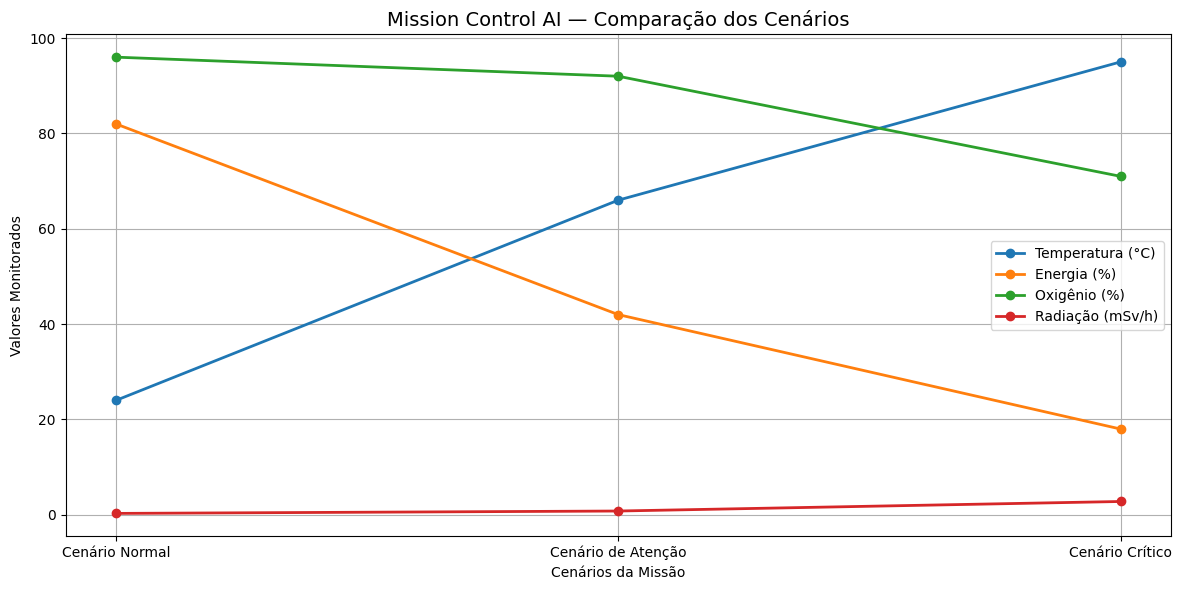

Gráfico salvo em: assets/cenarios_grafico.png


In [52]:
# GRÁFICO DOS CENÁRIOS
import matplotlib.pyplot as plt
import os

os.makedirs("assets", exist_ok=True)

plt.figure(figsize=(12, 6))

plt.plot(df_resultados["Cenário"], df_resultados["Temperatura (°C)"], marker="o", linewidth=2, label="Temperatura (°C)")
plt.plot(df_resultados["Cenário"], df_resultados["Energia (%)"], marker="o", linewidth=2, label="Energia (%)")
plt.plot(df_resultados["Cenário"], df_resultados["Oxigênio (%)"], marker="o", linewidth=2, label="Oxigênio (%)")
# Radiação
plt.plot(df_resultados["Cenário"], df_resultados["Radiação (mSv/h)"], marker="o", linewidth=2, label="Radiação (mSv/h)")

plt.title("Mission Control AI — Comparação dos Cenários", fontsize=14)
plt.xlabel("Cenários da Missão")
plt.ylabel("Valores Monitorados")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("assets/cenarios_grafico.png", bbox_inches="tight", dpi=300)
plt.show()

print("Gráfico salvo em: assets/cenarios_grafico.png")